In [ ]:
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.ensemble import RandomForestClassifier

# Evaluasi
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
import pandas as pd
train = pd.read_csv('/data_training.csv')
test = pd.read_csv('/data_testing.csv')

In [43]:
#Mengecek ukuran dataset
print("Ukuran data training :", train.shape)
print("Ukuran data testing  :", test.shape)

Ukuran data training : (857, 13)
Ukuran data testing  : (286, 12)


In [5]:
train.head()
test.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


In [6]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


Dari hasil describe(), terlihat bahwa setiap fitur memiliki rentang nilai yang berbeda-beda. Oleh karena itu diperlukan normalisasi data agar performa model lebih optimal.

In [9]:
#Mengecek Missing Value
train.isnull().sum()
test.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Berdasarkan hasil pengecekan missing value, seluruh variabel memiliki nilai 0 sehingga tidak terdapat data yang hilang pada dataset.

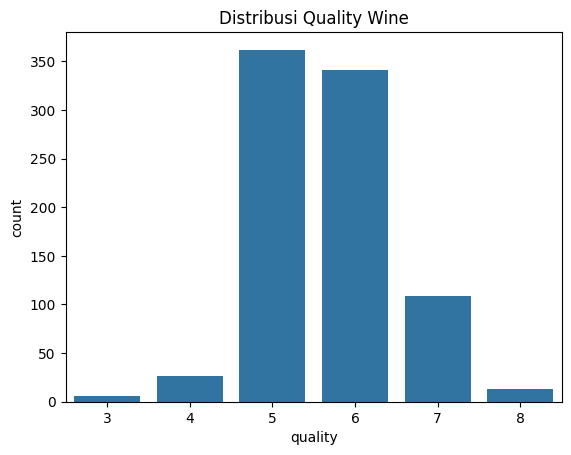

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

#Visualisasi Data
#Distribusi Quality
sns.countplot(x='quality', data=train)
plt.title('Distribusi Quality Wine')
plt.show()

Berdasarkan grafik distribusi quality, terlihat bahwa kualitas wine paling banyak berada pada nilai tertentu. Hal ini menunjukkan distribusi kelas pada dataset tidak sepenuhnya seimbang.

In [12]:
#Memisahkan Fitur dan Target
X = train.drop('quality', axis=1)
y = train['quality']

In [15]:
from sklearn.model_selection import train_test_split

#Membagi Data Training dan Validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [17]:
from sklearn.preprocessing import StandardScaler

#Feature Scaling (Normalisasi)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [19]:
from sklearn.ensemble import RandomForestClassifier

#Membuat Model Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [20]:
#Prediksi Data Validation
y_pred = model.predict(X_val_scaled)

In [22]:
from sklearn.metrics import accuracy_score

#Akurasi
accuracy = accuracy_score(y_val, y_pred)
print('Accuracy :', accuracy)

Accuracy : 0.5988372093023255


Model menghasilkan akurasi sebesar 0.59 atau 59%, artinya model mampu memprediksi kualitas wine dengan benar sebanyak 59% dari total data validation.

In [24]:
from sklearn.metrics import confusion_matrix

#Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
print(cm)

[[ 0  1  2  0  0]
 [ 0 47 20  0  0]
 [ 0 23 47  8  0]
 [ 0  1 11  9  0]
 [ 0  0  0  3  0]]


In [26]:
from sklearn.metrics import classification_report

#Classification Report
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.65      0.70      0.68        67
           6       0.59      0.60      0.59        78
           7       0.45      0.43      0.44        21
           8       0.00      0.00      0.00         3

    accuracy                           0.60       172
   macro avg       0.34      0.35      0.34       172
weighted avg       0.58      0.60      0.59       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
from sklearn.neighbors import KNeighborsClassifier

#KNN
knn_model = KNeighborsClassifier(
    n_neighbors=5
)# Training model
knn_model.fit(X_train_scaled, y_train)
# Prediksi validation
knn_pred = knn_model.predict(X_val_scaled)

# Accuracy
knn_acc = accuracy_score(y_val, knn_pred)
print("Accuracy :", knn_acc)

# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_val, knn_pred))

# Classification Report
print("\nClassification Report")
print(classification_report(y_val, knn_pred))

Accuracy : 0.5

Confusion Matrix
[[ 0  1  2  0  0]
 [ 2 39 26  0  0]
 [ 0 34 37  6  1]
 [ 0  4  7 10  0]
 [ 0  1  1  1  0]]

Classification Report
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.49      0.58      0.53        67
           6       0.51      0.47      0.49        78
           7       0.59      0.48      0.53        21
           8       0.00      0.00      0.00         3

    accuracy                           0.50       172
   macro avg       0.32      0.31      0.31       172
weighted avg       0.49      0.50      0.49       172



In [ ]:
Membandingkan Akurasi

In [40]:
print("\n===== PERBANDINGAN MODEL ====")
print("Accuracy Random Forest :", accuracy)
print("Accuracy KNN           :", knn_acc)



===== PERBANDINGAN MODEL ====
Accuracy Random Forest : 0.5988372093023255
Accuracy KNN           : 0.5


In [42]:
#Memilih Model Terbaik
if accuracy > knn_acc:
    best_model = model
    print("\nModel terbaik: Random Forest")
else:
    best_model = knn_model
    print("\nModel terbaik: KNN")


Model terbaik: Random Forest


In [27]:
#Scaling Data Testing
X_test_scaled = scaler.transform(test)

In [28]:
#Prediksi
prediksi = model.predict(X_test_scaled)

In [30]:
submission = pd.DataFrame({
    'id': test['Id'],
    'quality': prediksi
})

In [31]:
submission.head()

,id,quality
0,222,5
1,1514,5
2,417,5
3,754,5
4,516,5


In [32]:
submission.to_csv('hasilprediksi.csv', index=False)

In [33]:
from google.colab import files
files.download('hasilprediksi.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Pada penelitian ini dilakukan klasifikasi kualitas wine menggunakan algoritma Random Forest Classifier. Tahapan yang dilakukan meliputi preprocessing data, pengecekan missing value, normalisasi data, pelatihan model, evaluasi model, dan prediksi data testing. Berdasarkan hasil evaluasi, model memperoleh nilai akurasi yang cukup baik sehingga dapat digunakan untuk memprediksi kualitas wine pada dataset testing.